In [1]:

import math
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from collections import defaultdict


In [2]:
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [3]:
def largest_connected_component_subgraph(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        return G
    components = list(nx.connected_components(G))
    gcc_nodes = max(components, key=len)
    return G.subgraph(gcc_nodes).copy()


def approx_avg_shortest_path_length(
    G: nx.Graph,
    n_samples: int = 64,
    seed: int = 0
) -> float:

    rng = random.Random(seed)
    nodes = list(G.nodes())
    if len(nodes) <= 1:
        return 0.0

    sample_size = min(n_samples, len(nodes))
    sources = rng.sample(nodes, sample_size)

    per_source_means = []
    for s in sources:
        dist_dict = nx.single_source_shortest_path_length(G, s)
        dists = list(dist_dict.values())
        if len(dists) <= 1:
            continue
        per_source_means.append(sum(dists) / (len(dists) - 1))

    if not per_source_means:
        return float("nan")
    return float(np.mean(per_source_means))


def build_1d_ring(N: int, k: int = 2) -> nx.Graph:

    if k != 2:
        assert k % 2 == 0,
        G = nx.Graph()
        G.add_nodes_from(range(N))
        r = k // 2
        for i in range(N):
            for j in range(1, r + 1):
                G.add_edge(i, (i + j) % N)
                G.add_edge(i, (i - j) % N)
        return G
    return nx.cycle_graph(N)

def build_2d_torus(L: int) -> nx.Graph:

    G = nx.grid_2d_graph(L, L, periodic=True)
    mapping = {node: i for i, node in enumerate(G.nodes())}
    return nx.relabel_nodes(G, mapping)

def build_3d_torus(L: int) -> nx.Graph:

    G = nx.grid_graph(dim=[L, L, L])
    for x in range(L):
        for y in range(L):
            for z in range(L):
                G.add_edge((x, y, z), ((x + 1) % L, y, z))
                G.add_edge((x, y, z), (x, (y + 1) % L, z))
                G.add_edge((x, y, z), (x, y, (z + 1) % L))

    mapping = {node: i for i, node in enumerate(G.nodes())}
    return nx.relabel_nodes(G, mapping)

def build_er_gnp(N: int, k_avg: float = 4.0, seed: int = 0) -> nx.Graph:

    p = k_avg / (N - 1)
    return nx.gnp_random_graph(N, p, seed=seed, directed=False)

In [4]:
def fit_loglog(Ns, ds):
    Ns = np.array(Ns, dtype=float)
    ds = np.array(ds, dtype=float)
    mask = np.isfinite(ds) & (ds > 0) & (Ns > 0)
    x = np.log(Ns[mask])
    y = np.log(ds[mask])
    b, a = np.polyfit(x, y, 1)
    return a, b


In [5]:
N_list_1d_er = np.unique(np.logspace(np.log10(500), np.log10(5000), num=9).astype(int)).tolist()

L_list_2d = np.unique(np.logspace(np.log10(23), np.log10(70), num=9).astype(int)).tolist()
N_list_2d = [L * L for L in L_list_2d]

L_list_3d = np.unique(np.logspace(np.log10(8), np.log10(17), num=8).astype(int)).tolist()
N_list_3d = [L ** 3 for L in L_list_3d]

def reps_for_N(N: int) -> int:
    if N <= 800:
        return 12
    if N <= 2000:
        return 8
    return 5

def samples_for_N(N: int) -> int:
    if N <= 800:
        return 96
    if N <= 2000:
        return 64
    return 48


results = {
    "1D_Lattice": {"N": [], "d": [], "gcc_frac": []},
    "2D_Lattice": {"N": [], "d": [], "gcc_frac": []},
    "3D_Lattice": {"N": [], "d": [], "gcc_frac": []},
    "ER_Random": {"N": [], "d": [], "gcc_frac": []},
}

for N in N_list_1d_er:
    ds = []
    for r in range(reps_for_N(N)):
        G = build_1d_ring(N, k=2)
        d_hat = approx_avg_shortest_path_length(G, n_samples=samples_for_N(N), seed=GLOBAL_SEED + r)
        ds.append(d_hat)
    results["1D_Lattice"]["N"].append(N)
    results["1D_Lattice"]["d"].append(float(np.mean(ds)))
    results["1D_Lattice"]["gcc_frac"].append(1.0)

for L, N in zip(L_list_2d, N_list_2d):
    ds = []
    for r in range(reps_for_N(N)):
        G = build_2d_torus(L)
        d_hat = approx_avg_shortest_path_length(G, n_samples=samples_for_N(N), seed=GLOBAL_SEED + r)
        ds.append(d_hat)
    results["2D_Lattice"]["N"].append(N)
    results["2D_Lattice"]["d"].append(float(np.mean(ds)))
    results["2D_Lattice"]["gcc_frac"].append(1.0)

for L, N in zip(L_list_3d, N_list_3d):
    ds = []
    for r in range(reps_for_N(N)):
        G = build_3d_torus(L)
        d_hat = approx_avg_shortest_path_length(G, n_samples=samples_for_N(N), seed=GLOBAL_SEED + r)
        ds.append(d_hat)
    results["3D_Lattice"]["N"].append(N)
    results["3D_Lattice"]["d"].append(float(np.mean(ds)))
    results["3D_Lattice"]["gcc_frac"].append(1.0)

for N in N_list_1d_er:
    ds = []
    gcc_fracs = []
    for r in range(reps_for_N(N)):
        G = build_er_gnp(N, k_avg=4.0, seed=GLOBAL_SEED + r)
        # Use giant component if disconnected
        if nx.is_connected(G):
            H = G
        else:
            H = largest_connected_component_subgraph(G)
        gcc_fracs.append(H.number_of_nodes() / N)

        d_hat = approx_avg_shortest_path_length(H, n_samples=samples_for_N(N), seed=GLOBAL_SEED + 1000 + r)
        ds.append(d_hat)

    results["ER_Random"]["N"].append(N)
    results["ER_Random"]["d"].append(float(np.mean(ds)))
    results["ER_Random"]["gcc_frac"].append(float(np.mean(gcc_fracs)))

fits = {}
for key in results:
    a, b = fit_loglog(results[key]["N"], results[key]["d"])
    fits[key] = {"a": a, "b": b}

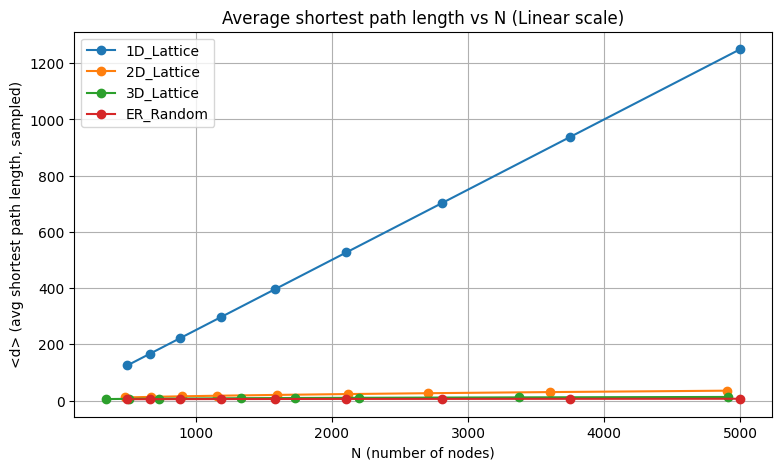

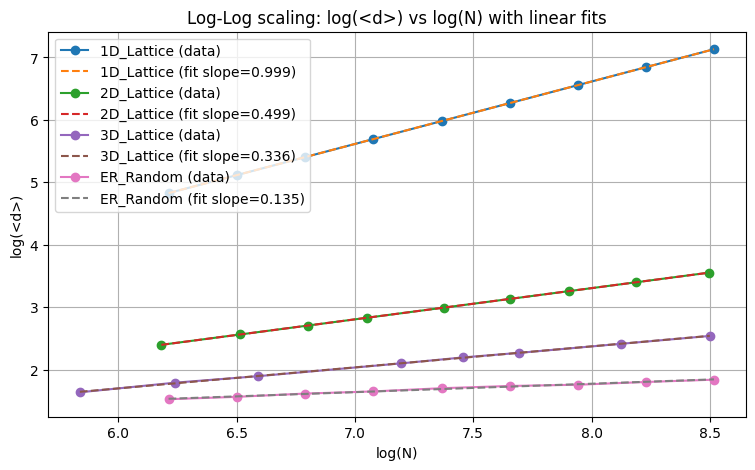

===== Log-Log Fit Slopes (log(d) = a + b log(N)) =====
1D_Lattice   : slope b = 0.9993
2D_Lattice   : slope b = 0.4992
3D_Lattice   : slope b = 0.3364
ER_Random    : slope b = 0.1350

===== ER Giant Component Fraction (mean over repetitions) =====
N=  499 : GCC fraction ≈ 0.979
N=  666 : GCC fraction ≈ 0.979
N=  889 : GCC fraction ≈ 0.981
N= 1185 : GCC fraction ≈ 0.982
N= 1581 : GCC fraction ≈ 0.978
N= 2108 : GCC fraction ≈ 0.982
N= 2811 : GCC fraction ≈ 0.980
N= 3749 : GCC fraction ≈ 0.979
N= 4999 : GCC fraction ≈ 0.979


In [6]:
plt.figure(figsize=(9, 5))
for key in ["1D_Lattice", "2D_Lattice", "3D_Lattice", "ER_Random"]:
    plt.plot(results[key]["N"], results[key]["d"], marker="o", label=key)
plt.xlabel("N (number of nodes)")
plt.ylabel("<d> (avg shortest path length, sampled)")
plt.title("Average shortest path length vs N (Linear scale)")
plt.grid(True)
plt.legend()
plt.show()


plt.figure(figsize=(9, 5))
for key in ["1D_Lattice", "2D_Lattice", "3D_Lattice", "ER_Random"]:
    Ns = np.array(results[key]["N"], dtype=float)
    ds = np.array(results[key]["d"], dtype=float)

    plt.plot(np.log(Ns), np.log(ds), marker="o", linestyle="-", label=f"{key} (data)")

    a = fits[key]["a"]
    b = fits[key]["b"]
    x_line = np.linspace(np.log(Ns.min()), np.log(Ns.max()), 100)
    y_line = a + b * x_line
    plt.plot(x_line, y_line, linestyle="--", label=f"{key} (fit slope={b:.3f})")

plt.xlabel("log(N)")
plt.ylabel("log(<d>)")
plt.title("Log-Log scaling: log(<d>) vs log(N) with linear fits")
plt.grid(True)
plt.legend()
plt.show()


print("===== Log-Log Fit Slopes (log(d) = a + b log(N)) =====")
for key in ["1D_Lattice", "2D_Lattice", "3D_Lattice", "ER_Random"]:
    print(f"{key:12s} : slope b = {fits[key]['b']:.4f}")

print("\n===== ER Giant Component Fraction (mean over repetitions) =====")
for N, frac in zip(results["ER_Random"]["N"], results["ER_Random"]["gcc_frac"]):
    print(f"N={N:5d} : GCC fraction ≈ {frac:.3f}")